# EDA Block A: Global Structure And Target Behavior

This notebook implements point 6 from `docs/plan.md`.

Scope:
- row and column counts plus unique-entity summaries for all contest tables
- class imbalance analysis for `scored_after` overall and by checkpoint, position, home/away, and formation
- temporal distribution of positives by checkpoint sequence
- participation dynamics for `minute_in`, `minute_out`, and `subbed`

Protocol note:
- if `data/splits/modeling_row_folds.csv` exists, target-behavior analysis is run on the development partition only
- holdout rows are excluded from detailed target EDA to stay aligned with the fixed evaluation protocol
- `minute_out` and `subbed` are treated as descriptive variables only, because the leakage audit flagged them as future-looking for modeling


In [10]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
plt.style.use("ggplot")


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "docs").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing `data/` and `docs/`.")


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
SPLIT_DIR = DATA_DIR / "splits"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Split directory exists: {SPLIT_DIR.exists()}")


Project root: /Users/jan/Documents/competitions/hackatons/WEC_26
Data directory: /Users/jan/Documents/competitions/hackatons/WEC_26/data
Split directory exists: True


In [11]:
TABLE_FILES = [
    "players_quarters_final.csv",
    "player_appearance_pass.csv",
    "player_appearance_behaviour_under_pressure.csv",
    "player_appearance_run.csv",
    "player_appearance_shot_limited.csv",
]


def load_table(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].replace({"NULL": pd.NA, "": pd.NA})
    return df


tables = {name: load_table(DATA_DIR / name) for name in TABLE_FILES}
main_full = tables["players_quarters_final.csv"].copy()

split_path = SPLIT_DIR / "modeling_row_folds.csv"
if split_path.exists():
    main_with_splits = pd.read_csv(split_path)
    analysis_main = main_with_splits[main_with_splits["partition_role"] == "development"].copy()
    holdout_rows = int((main_with_splits["partition_role"] == "holdout").sum())
    print(f"Using development partition for target EDA: {len(analysis_main):,} rows")
    print(f"Excluded holdout rows: {holdout_rows:,}")
else:
    main_with_splits = main_full.copy()
    analysis_main = main_full.copy()
    print("No split artifact found. Using full main table for target EDA.")


Using development partition for target EDA: 2,830 rows
Excluded holdout rows: 656


In [12]:
def dataset_inventory(name: str, df: pd.DataFrame) -> dict:
    return {
        "table": name,
        "rows": len(df),
        "columns": len(df.columns),
        "missing_cells": int(df.isna().sum().sum()),
        "unique_fixture_id": int(df["fixture_id"].nunique()) if "fixture_id" in df.columns else pd.NA,
        "unique_player_id": int(df["player_id"].nunique()) if "player_id" in df.columns else pd.NA,
        "unique_player_appearance_id": int(df["player_appearance_id"].nunique()) if "player_appearance_id" in df.columns else pd.NA,
        "unique_event_id": int(df["id"].nunique()) if "id" in df.columns else pd.NA,
    }


def target_summary(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    summary = (
        df.groupby(group_col, dropna=False)["scored_after"]
        .agg(rows="size", positives="sum", target_rate="mean")
        .reset_index()
    )
    summary["negative_count"] = summary["rows"] - summary["positives"]
    summary["positive_share_pct"] = (summary["target_rate"] * 100).round(2)
    return summary.sort_values(["target_rate", "rows"], ascending=[False, False]).reset_index(drop=True)


def ordered_checkpoint_summary(df: pd.DataFrame) -> pd.DataFrame:
    checkpoint_order = ["H1_15", "H1_30", "H1_45", "H2_15", "H2_30", "H2_45", "ET1_15"]
    summary = target_summary(df, "checkpoint")
    summary["checkpoint"] = pd.Categorical(summary["checkpoint"], categories=checkpoint_order, ordered=True)
    return summary.sort_values("checkpoint").reset_index(drop=True)


def plot_rate_bar(ax, df: pd.DataFrame, label_col: str, title: str, rotate: int = 0) -> None:
    labels = df[label_col].astype(str)
    rates = df["target_rate"] * 100
    ax.bar(labels, rates, color="#2f6b8a")
    ax.set_title(title)
    ax.set_ylabel("Positive rate (%)")
    ax.tick_params(axis="x", rotation=rotate)
    for idx, value in enumerate(rates):
        ax.text(idx, value + 0.08, f"n={int(df.iloc[idx]['rows'])}", ha="center", va="bottom", fontsize=8)


In [13]:
inventory = pd.DataFrame([dataset_inventory(name, df) for name, df in tables.items()])
inventory = inventory.sort_values("table").reset_index(drop=True)

main_entity_summary = pd.DataFrame(
    {
        "metric": [
            "Rows in full main table",
            "Rows used for target EDA",
            "Unique fixtures",
            "Unique players",
            "Unique player appearances",
            "Unique checkpoints",
            "Unique positions",
            "Unique formations",
        ],
        "value": [
            len(main_full),
            len(analysis_main),
            analysis_main["fixture_id"].nunique(),
            analysis_main["player_id"].nunique(),
            analysis_main["player_appearance_id"].nunique(),
            analysis_main["checkpoint"].nunique(),
            analysis_main["position"].nunique(),
            analysis_main["formation"].nunique(),
        ],
    }
)

fixture_size_summary = analysis_main.groupby("fixture_id").size().describe().to_frame(name="rows_per_fixture")

display(Markdown("## Table Inventory"))
display(inventory)

display(Markdown("## Main Table Entity Summary"))
display(main_entity_summary)

display(Markdown("## Rows Per Fixture (development partition if available)"))
display(fixture_size_summary)


## Table Inventory

,table,rows,columns,missing_cells,unique_fixture_id,unique_player_id,unique_player_appearance_id,unique_event_id
0,player_appearance_behaviour_under_pressure.csv,12185,10,6456,<NA>,<NA>,923,12185
1,player_appearance_pass.csv,29795,7,98,<NA>,<NA>,959,29795
2,player_appearance_run.csv,35133,10,0,<NA>,<NA>,968,35133
3,player_appearance_shot_limited.csv,780,12,1344,<NA>,<NA>,453,780
4,players_quarters_final.csv,3486,33,0,31,307,869,<NA>


## Main Table Entity Summary

,metric,value
0,Rows in full main table,3486
1,Rows used for target EDA,2830
2,Unique fixtures,25
3,Unique players,303
4,Unique player appearances,702
5,Unique checkpoints,7
6,Unique positions,4
7,Unique formations,10


## Rows Per Fixture (development partition if available)

,rows_per_fixture
count,25.000000
mean,113.200000
std,11.877851
min,105.000000
25%,110.000000
50%,110.000000
75%,110.000000
max,154.000000


In [14]:
overall_target = pd.DataFrame(
    {
        "rows": [len(analysis_main)],
        "positives": [int(analysis_main["scored_after"].sum())],
        "negatives": [int((1 - analysis_main["scored_after"]).sum())],
        "target_rate": [analysis_main["scored_after"].mean()],
    }
)
overall_target["target_rate_pct"] = (overall_target["target_rate"] * 100).round(2)

checkpoint_summary = ordered_checkpoint_summary(analysis_main)
position_summary = target_summary(analysis_main, "position")
home_summary = target_summary(
    analysis_main.assign(home_away=np.where(analysis_main["is_home"], "home", "away")),
    "home_away",
)
formation_summary = target_summary(analysis_main, "formation")
top_formations = formation_summary.sort_values("rows", ascending=False).head(12).reset_index(drop=True)

display(Markdown("## Overall Class Imbalance"))
display(overall_target)

display(Markdown("## `scored_after` By Checkpoint"))
display(checkpoint_summary)

display(Markdown("## `scored_after` By Position"))
display(position_summary)

display(Markdown("## `scored_after` By Home/Away"))
display(home_summary)

display(Markdown("## `scored_after` By Formation (top 12 by row count)"))
display(top_formations)


## Overall Class Imbalance

,rows,positives,negatives,target_rate,target_rate_pct
0,2830,165,2665,0.058304,5.83


## `scored_after` By Checkpoint

,checkpoint,rows,positives,target_rate,negative_count,positive_share_pct
0,H1_15,549,52,0.094718,497,9.47
1,H1_30,549,41,0.074681,508,7.47
2,H1_45,549,34,0.061931,515,6.19
3,H2_15,549,19,0.034608,530,3.46
4,H2_30,549,16,0.029144,533,2.91
5,H2_45,43,2,0.046512,41,4.65
6,ET1_15,42,1,0.023810,41,2.38


## `scored_after` By Position

,position,rows,positives,target_rate,negative_count,positive_share_pct
0,A,510,66,0.129412,444,12.94
1,M,1050,66,0.062857,984,6.29
2,D,1012,33,0.032609,979,3.26
3,G,258,0,0.000000,258,0.00


## `scored_after` By Home/Away

,home_away,rows,positives,target_rate,negative_count,positive_share_pct
0,away,1416,96,0.067797,1320,6.78
1,home,1414,69,0.048798,1345,4.88


## `scored_after` By Formation (top 12 by row count)

,formation,rows,positives,target_rate,negative_count,positive_share_pct
0,4-2-3-1,737,49,0.066486,688,6.65
1,4-3-3,715,31,0.043357,684,4.34
2,4-1-4-1,380,26,0.068421,354,6.84
3,4-4-2,374,37,0.098930,337,9.89
4,3-4-3,275,10,0.036364,265,3.64
5,5-4-1,110,4,0.036364,106,3.64
6,3-4-2-1,74,4,0.054054,70,5.41
7,5-2-3,55,4,0.072727,51,7.27
8,4-1-3-2,55,0,0.000000,55,0.00
9,4-2-4,55,0,0.000000,55,0.00


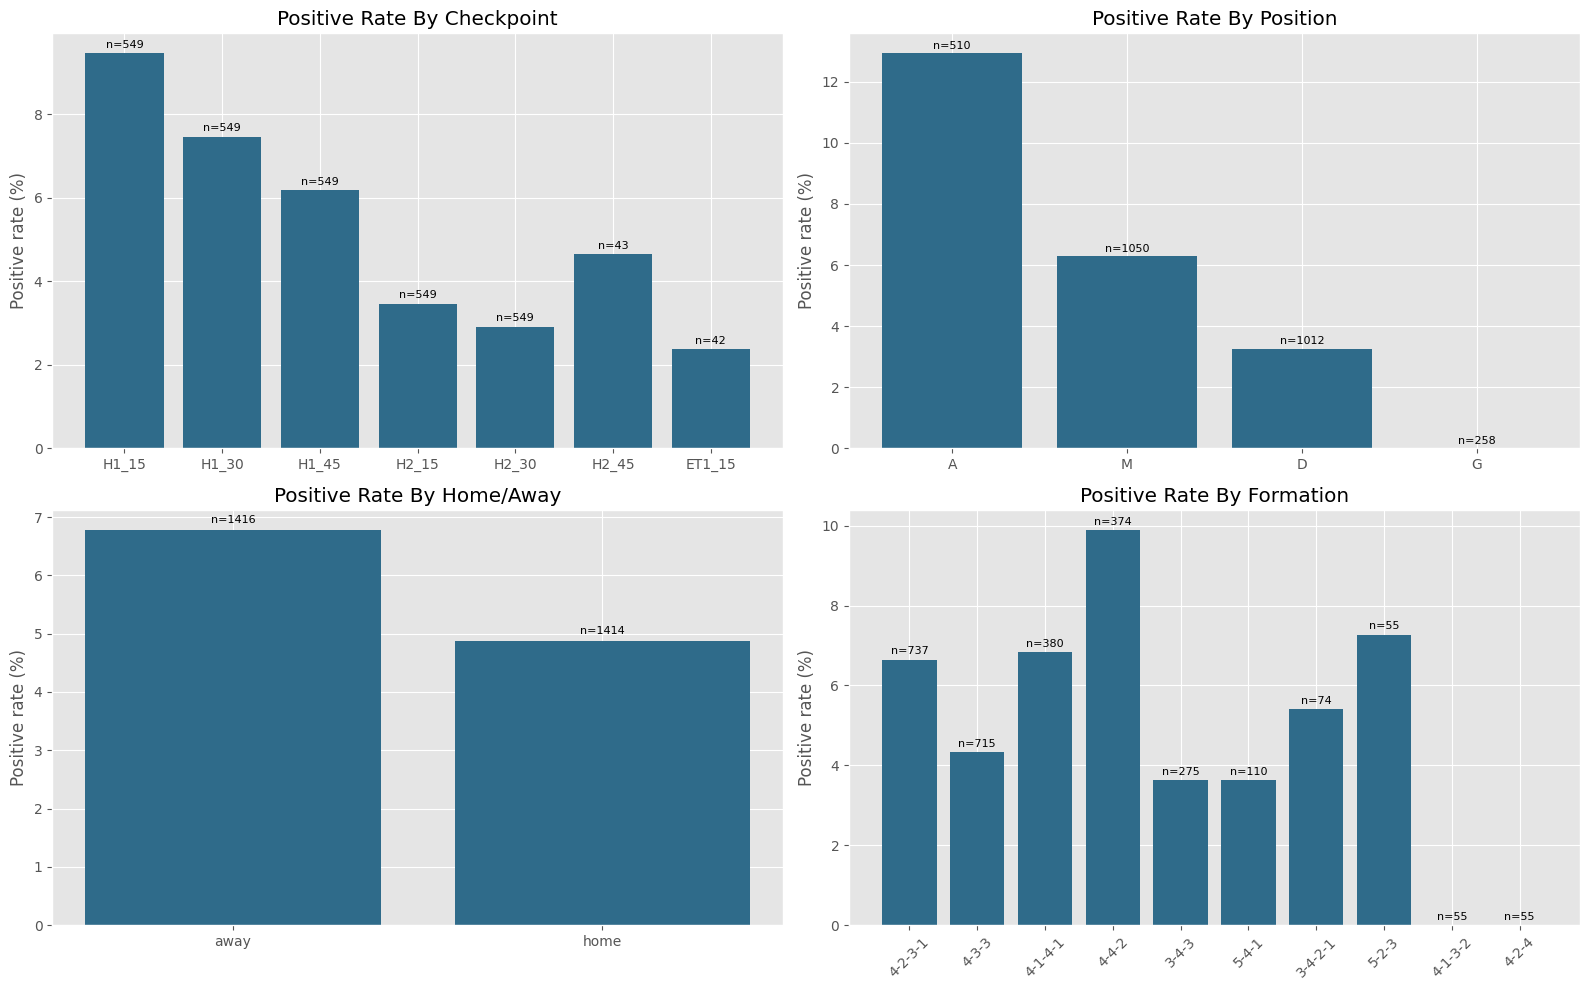

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_rate_bar(axes[0, 0], checkpoint_summary, "checkpoint", "Positive Rate By Checkpoint")
plot_rate_bar(axes[0, 1], position_summary, "position", "Positive Rate By Position")
plot_rate_bar(axes[1, 0], home_summary, "home_away", "Positive Rate By Home/Away")
plot_rate_bar(axes[1, 1], top_formations, "formation", "Positive Rate By Formation", rotate=45)

plt.tight_layout()
plt.show()


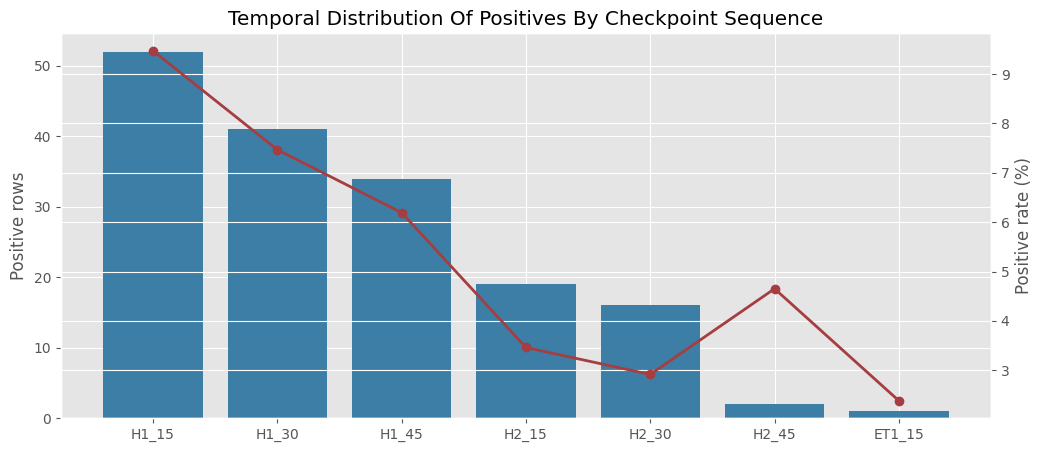

In [16]:
checkpoint_timeline = checkpoint_summary.copy()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(checkpoint_timeline["checkpoint"].astype(str), checkpoint_timeline["positives"], color="#3d7ea6")
ax1.set_ylabel("Positive rows")
ax1.set_title("Temporal Distribution Of Positives By Checkpoint Sequence")

ax2 = ax1.twinx()
ax2.plot(
    checkpoint_timeline["checkpoint"].astype(str),
    checkpoint_timeline["target_rate"] * 100,
    color="#a63d40",
    marker="o",
    linewidth=2,
)
ax2.set_ylabel("Positive rate (%)")

plt.show()


## Participation Dynamics

The next section is descriptive only. The leakage audit showed that `minute_out` and `subbed` should not be used directly as modeling features for earlier checkpoints, but they remain useful for understanding player participation patterns.


In [17]:
minute_in_focus = analysis_main.loc[analysis_main["minute_in"] != 1, "minute_in"].dropna()
minute_out_focus = analysis_main.loc[analysis_main["minute_out"] != 90, "minute_out"].dropna()

participation_summary = pd.DataFrame(
    {
        "metric": [
            "minute_in median (excluding 1)",
            "minute_in p90 (excluding 1)",
            "minute_in non-default rows",
            "minute_out median (excluding 90)",
            "minute_out p90 (excluding 90)",
            "minute_out non-default rows",
            "subbed share",
        ],
        "value": [
            minute_in_focus.median(),
            minute_in_focus.quantile(0.9),
            len(minute_in_focus),
            minute_out_focus.median(),
            minute_out_focus.quantile(0.9),
            len(minute_out_focus),
            analysis_main["subbed"].mean(),
        ],
    }
)

participation_by_checkpoint = (
    analysis_main.groupby("checkpoint", dropna=False)
    .agg(
        rows=("checkpoint", "size"),
        minute_in_median=("minute_in", "median"),
        minute_out_median=("minute_out", "median"),
        subbed_rate=("subbed", "mean"),
    )
    .reset_index()
)
participation_by_checkpoint["checkpoint"] = pd.Categorical(
    participation_by_checkpoint["checkpoint"],
    categories=["H1_15", "H1_30", "H1_45", "H2_15", "H2_30", "H2_45", "ET1_15"],
    ordered=True,
)
participation_by_checkpoint = participation_by_checkpoint.sort_values("checkpoint").reset_index(drop=True)

display(Markdown("## Participation Summary"))
display(participation_summary)

display(Markdown("## Participation By Checkpoint"))
display(participation_by_checkpoint)



## Participation Summary

,metric,value
0,minute_in median (excluding 1),62.000000
1,minute_in p90 (excluding 1),74.000000
2,minute_in non-default rows,220.000000
3,minute_out median (excluding 90),78.000000
4,minute_out p90 (excluding 90),120.000000
5,minute_out non-default rows,1171.000000
6,subbed share,0.364311


## Participation By Checkpoint

,checkpoint,rows,minute_in_median,minute_out_median,subbed_rate
0,H1_15,549,1.0,90.0,0.437158
1,H1_30,549,1.0,90.0,0.437158
2,H1_45,549,1.0,90.0,0.435337
3,H2_15,549,1.0,90.0,0.358834
4,H2_30,549,1.0,90.0,0.183971
5,H2_45,43,1.0,120.0,0.279070
6,ET1_15,42,22.5,120.0,0.047619


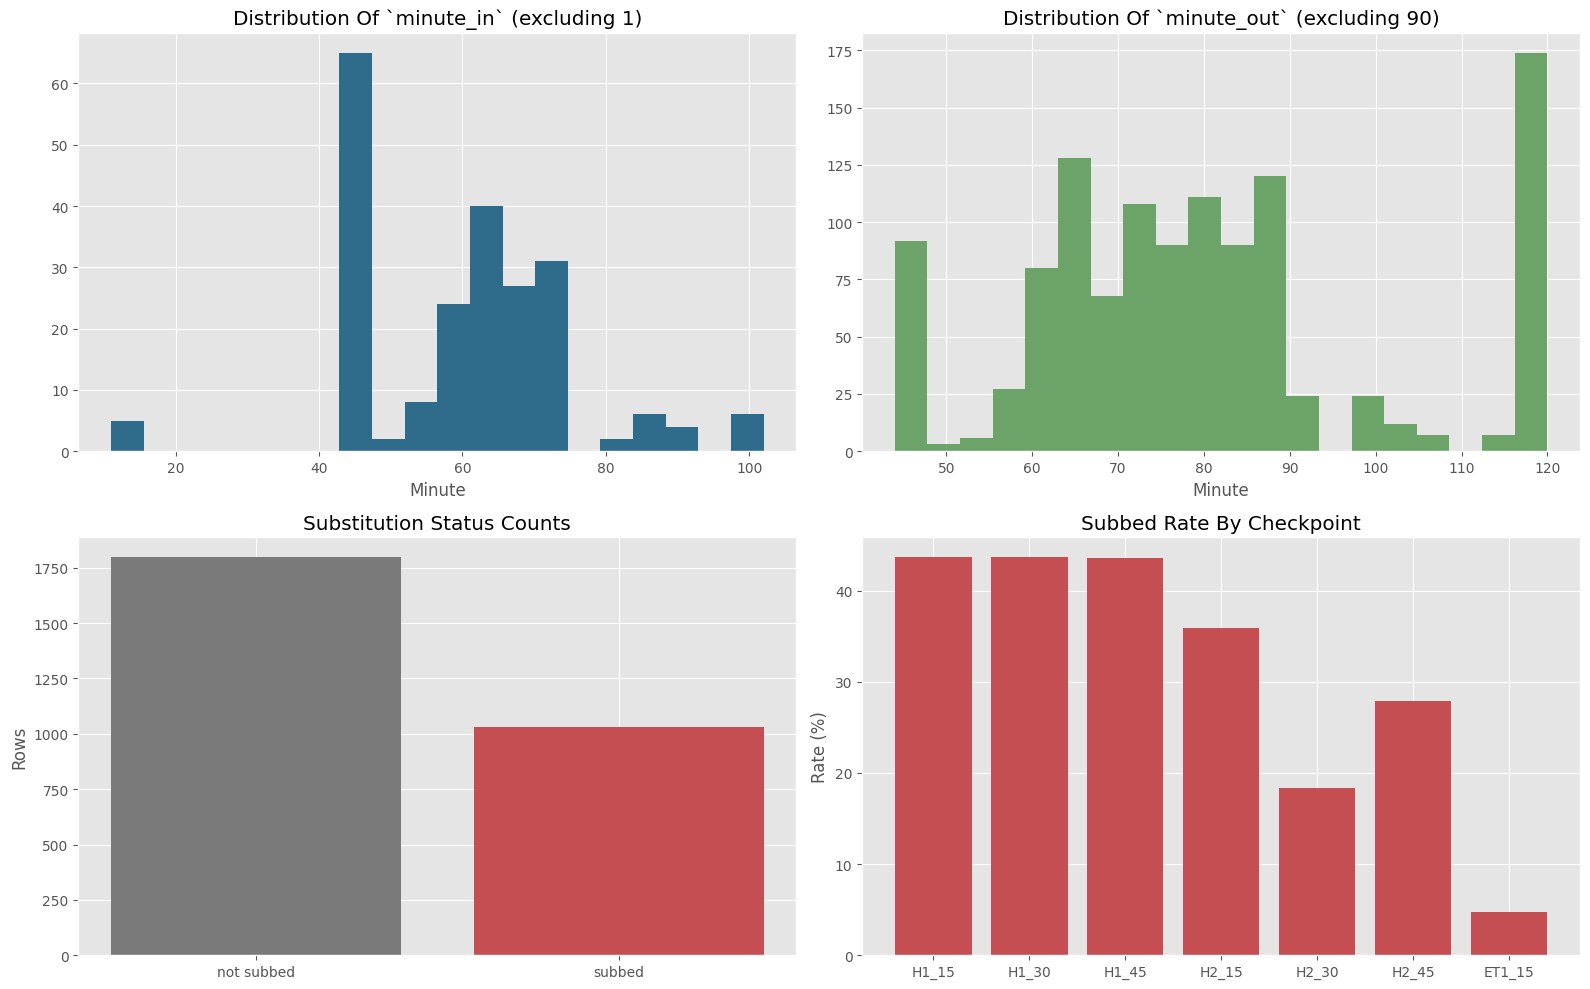

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(minute_in_focus, bins=20, color="#2f6b8a")
axes[0, 0].set_title("Distribution Of `minute_in` (excluding 1)")
axes[0, 0].set_xlabel("Minute")

axes[0, 1].hist(minute_out_focus, bins=20, color="#6ba368")
axes[0, 1].set_title("Distribution Of `minute_out` (excluding 90)")
axes[0, 1].set_xlabel("Minute")

axes[1, 0].bar(["not subbed", "subbed"], analysis_main["subbed"].fillna(False).value_counts().reindex([False, True], fill_value=0).values, color=["#7a7a7a", "#c44e52"])
axes[1, 0].set_title("Substitution Status Counts")
axes[1, 0].set_ylabel("Rows")

axes[1, 1].bar(participation_by_checkpoint["checkpoint"].astype(str), participation_by_checkpoint["subbed_rate"] * 100, color="#c44e52")
axes[1, 1].set_title("Subbed Rate By Checkpoint")
axes[1, 1].set_ylabel("Rate (%)")

plt.tight_layout()
plt.show()
